# Clean IWQIS Site Data

The IWQIS data is broken down into some number of sites (100 < n < 600), most of which are useless garbage for one of the following reasons:
- the site is listed in `site.csv` but the full dataset has no data on the site (I think this is typically because a site is private or represents a single discrete sample from a point in time)
- the site doesn't has very little or no nitrogen data
- the site has data but has been operational for very little time (< 1yrs).

The point of this notebook is twofold:
1. Isolate the sites actually useful for this project
2. Illustrate why the final list of sites was chosen

The findings from this notebook were used to create the filtering protocol in `make_water.py`.

Let us proceed.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

WATER_RAW = Path("../../src/data/raw/water/")

# site_clean is constructed from site.csv.
# site.csv has an issue with poorly escaped quotes on entry 63
# this is the result of fixing that specific line.
site_data_filepath = WATER_RAW / "site_clean.csv"
measures_data = WATER_RAW / "measures.csv"

In [4]:
# load the site data from site_clean
# use extra options to ensure bad CSV entries detected
site_df = pd.read_csv(site_data_filepath, engine='python', on_bad_lines='warn')
print(site_df.columns)
print(site_df.shape[0]) # notice the large number of sites

Index(['uid', 'nickname', 'latitude', 'longitude', 'river', 'road', 'town',
       'state', 'draining_area', 'icao', 'description', 'funding',
       'operator_uid', 'colloc_uid', 'link_uid', 'downstream_uid',
       'upstream_uid', 'private', 'status', 'status_message', 'deployed_at',
       'discontinued_at'],
      dtype='str')
569


In [5]:
# get an idea of the data
site_df[["uid", "latitude", "longitude"]]

,uid,latitude,longitude
0,06604000,43.4697,-95.1236
1,CTZ00001,41.6571,-91.5416
2,SCN0001,13.1812,-86.3730
3,A,41.6938,-91.5481
4,JIMTEST,-99.0000,-99.0000
...,...,...,...
564,WQS0062,42.7771,-95.5300
565,WQS0070,42.2572,-92.2793
566,WQS0071,42.1548,-92.0057
567,WQS0073,42.6515,-95.2500


In [7]:
# get the full iwqis dataset (doesn't include USGS sites)
# modified from earlier code to fit annoying refactor
import sys
sys.path.insert(0, "../../")
from src.build.util.iwqis import _get_full_data

full_data = _get_full_data()

Reassembling 'iwqis_alldata.csv'
Expected: 42,394,345 rows across 85 chunks
Found 85 chunks to merge (order per the manifest). Proceeding...
  Reading chunk 85/85: /Users/isaac/dev/sustag/src/data/raw/water/chunks/iwqis_alldata_chunk84.csv
Reassembled 42,394,345 rows.


In [8]:
# get the number of unique sites that actually appear in the dataset
print("Unique uids in full data:", full_data["site_uid"].unique().shape[0])
print("Unique uids in site data:", site_df["uid"].unique().shape[0])

print("\n---------------------------------\n")

# for good measure more info about the datasets:
print(full_data.columns)
print("\n---------------------------------\n")

for col in site_df.columns:
    print(f"{col} distinct:", len(site_df[col].unique()))

Unique uids in full data: 160
Unique uids in site data: 569

---------------------------------

Index(['site_uid', 'datetime', 'nitrate_con', 'r_exc', 'm_exc', 'temp_water',
       'ph', 'spec_cond', 'diss_oxy_con', 'diss_oxy_sat', 'chloro_v',
       'chloro_con', 'turbi_mean', 'turbi_var', 'turbi_med', 'turbi_bes',
       'turbi_min', 'turbi_max', 'dts_temp_water', 'phosphate_con', 'ph_v2',
       'spec_cond_v2', 'diss_oxy_con_v2', 'diss_oxy_sat_v2', 'turbi_mean_v2'],
      dtype='str')

---------------------------------

uid distinct: 569
nickname distinct: 168
latitude distinct: 533
longitude distinct: 537
river distinct: 110
road distinct: 120
town distinct: 131
state distinct: 4
draining_area distinct: 118
icao distinct: 48
description distinct: 103
funding distinct: 15
operator_uid distinct: 4
colloc_uid distinct: 74
link_uid distinct: 81
downstream_uid distinct: 37
upstream_uid distinct: 42
private distinct: 2
status distinct: 3
status_message distinct: 33
deployed_at distinct: 

THERE AREN'T AS MANY SITES IN THE FULL DATASET (160) AS THERE ARE IN THE `site.csv` METADATE FILE (569). This next cell explains why:

In [9]:
print([s for s in full_data.site_uid.unique() if s.startswith("WQ") == False])

['9903   ', 'ARS0001', 'SCN0001', 'SCN0002', 'SCNOOO1', 'UNKNOWN', 'WW00001', 'WW00002']


Almost all of the sites in the fulldataset are marekd "WQ", for "Water Quality". These are sites maintained by Iowa/not the feds. The fulldataset also doesn't contain any of the many "CTZ" sites ("citizn" sites) listed in the `sites.csv` file. These citizen sites are places where volunteers collected samples (or sometimes just a single sample).

## Identifying Relevant Sites

We now wish to determine which of these remaining 160 "real sites" are not garbage. There are two ways a site can be irrelevant:
- it can have very little nitrogen data -- if the nitrogen data is incredibly sparse, the site is useless to us
- it can have a very small operational timeframe, if the site has only been in operation for < 1yr, we won't be able to do much with it.

We now identify all sites which both have a lot of nitrogen data and have been collecting data for some amount of time.

In [10]:
# get the unique uids and store them
uids = list(full_data['site_uid'].unique())
print(uids)

# build a dictionary of dataframes, one for each site
# this can take a while, written in for loop instead of
# list comprehension to get status updates
data_by_site = {}
for i,uid in enumerate(uids):
    data_by_site[uid] = full_data[full_data.site_uid == uid]
    if i % 10 == 0:
        print(f"processed {i} / {len(uids)} uids")

['9903   ', 'ARS0001', 'SCN0001', 'SCN0002', 'SCNOOO1', 'UNKNOWN', 'WQP0001', 'WQP0002', 'WQP0003', 'WQP0004', 'WQP0005', 'WQP0006', 'WQP0007', 'WQP0008', 'WQP0009', 'WQP0010', 'WQP0011', 'WQP0012', 'WQP0013', 'WQP0014', 'WQP0015', 'WQP0016', 'WQS0001', 'WQS0002', 'WQS0003', 'WQS0004', 'WQS0005', 'WQS0006', 'WQS0007', 'WQS0008', 'WQS0009', 'WQS0010', 'WQS0011', 'WQS0012', 'WQS0013', 'WQS0014', 'WQS0015', 'WQS0016', 'WQS0017', 'WQS0018', 'WQS0019', 'WQS0020', 'WQS0021', 'WQS0022', 'WQS0023', 'WQS0024', 'WQS0025', 'WQS0026', 'WQS0027', 'WQS0028', 'WQS0029', 'WQS0030', 'WQS0031', 'WQS0032', 'WQS0033', 'WQS0034', 'WQS0035', 'WQS0036', 'WQS0037', 'WQS0038', 'WQS0039', 'WQS0040', 'WQS0041', 'WQS0042', 'WQS0043', 'WQS0044', 'WQS0045', 'WQS0046', 'WQS0047', 'WQS0048', 'WQS0049', 'WQS0050', 'WQS0051', 'WQS0052', 'WQS0053', 'WQS0054', 'WQS0055', 'WQS0056', 'WQS0058', 'WQS0059', 'WQS0060', 'WQS0061', 'WQS0062', 'WQS0063', 'WQS0064', 'WQS0065', 'WQS0066', 'WQS0067', 'WQS0068', 'WQS0069', 'WQS0070'

In [11]:
###################
### SPARSITY CHECKS
###################

# this gets the % of columns in the site that have nitrogen data
def measure_nitrate_data(uid):
    df = data_by_site[uid]
    num_entries = df["nitrate_con"].count()
    return uid, num_entries/df.shape[0]

# make a list of pairs (site_uid, % nonempty nitrogen data)
pairs = [measure_nitrate_data(uid) for uid in uids]

# new dataframe, we'll add to it
site_metadata = pd.DataFrame(pairs, columns=['site_uid', 'data_count'])

# print out the number of sites meeting or 
# exceeding 0.0, 0.1, ... , 0.9, 1.0 threshold counts
print(f"{'Cuttoff Percent':<20} {'Count':<10}")
for i in range(11):
    count = site_metadata[site_metadata["data_count"] >= i/10]["data_count"].count()
    print(f"{str(i/10):<20} {str(count):<10}")

Cuttoff Percent      Count     
0.0                  160       
0.1                  132       
0.2                  130       
0.3                  130       
0.4                  128       
0.5                  125       
0.6                  123       
0.7                  116       
0.8                  109       
0.9                  80        
1.0                  5         


Looks like if we throw away everything with a nitrogen sparsity of 0.6 or lower, we're not losing many sites. We can manually check the sites in the 0.2-0.6 range later.

Now we investigate the longevity of the various sites. We get all sites with sparsity above a set threshold/cutoff and then count the number of sites whose (latest entry date - earliest entry date) is 0, 1, 2, etc via a histogram.

In [12]:
####################
### LONGEVITY CHECKS
####################

import plotly.express as px
from datetime import datetime

# get the (latest - earliest) difference in years
# lucky for us, the data is already sorted by date
# earliest date in row 0, latest date in last row
# this saves us from converting all of the date strings
# into datetimes and finding the min and max, which takes
# forever
def get_year_diff(uid):
    dt = data_by_site[uid]['datetime']
    early = datetime.fromisoformat(dt.iloc[0])
    late = datetime.fromisoformat(dt.iloc[-1])
    return (late - early).total_seconds() / (365.25 * 24 * 3600)

# add longevity to the site_metadata dataframe
site_metadata["lifespan"] = [get_year_diff(uid) for uid in site_metadata.site_uid.unique()]

In [13]:
# RUN THIS A FEW TIMES FOR DIFFERENT CUTOFF VALUES
cutoff = 0.9
x = site_metadata[site_metadata.data_count >= cutoff]
fig = px.histogram(x, x="lifespan", nbins=40)
fig.show()

What are the sites with nearly 0 difference between the earliest and latest start dates? Let's investigate by looking at the full time series plots.

uid        count        min date     max date     diff         reported diff  
9903       0.000000     2022-11-21   2022-11-21   0.000063     0.000063       
ARS0001    0.000000     2020-08-07   2020-08-27   0.054799     0.054799       
SCN0001    0.000000     2019-10-03   2020-06-26   0.730090     0.730090       
SCN0002    0.000000     2019-11-07   2019-11-16   0.024047     0.024047       
SCNOOO1    0.000000     2019-11-07   2019-11-07   0.000008     0.000008       
UNKNOWN    0.000000     2020-07-09   2020-07-09   0.000038     0.000038       
WQP0002    0.999732     2022-11-21   2023-06-13   0.558655     0.558655       
WQP0010    0.997355     2025-04-22   2026-06-08   1.127491     1.127491       
WQP0011    0.872963     2025-05-06   2026-06-08   1.089389     1.089389       
WQP0012    0.922190     2025-06-13   2026-06-08   0.985257     0.985257       
WQP0013    0.917313     2025-06-09   2026-06-08   0.996100     0.996100       
WQP0014    0.817970     2025-07-29   2026-06-08   0.

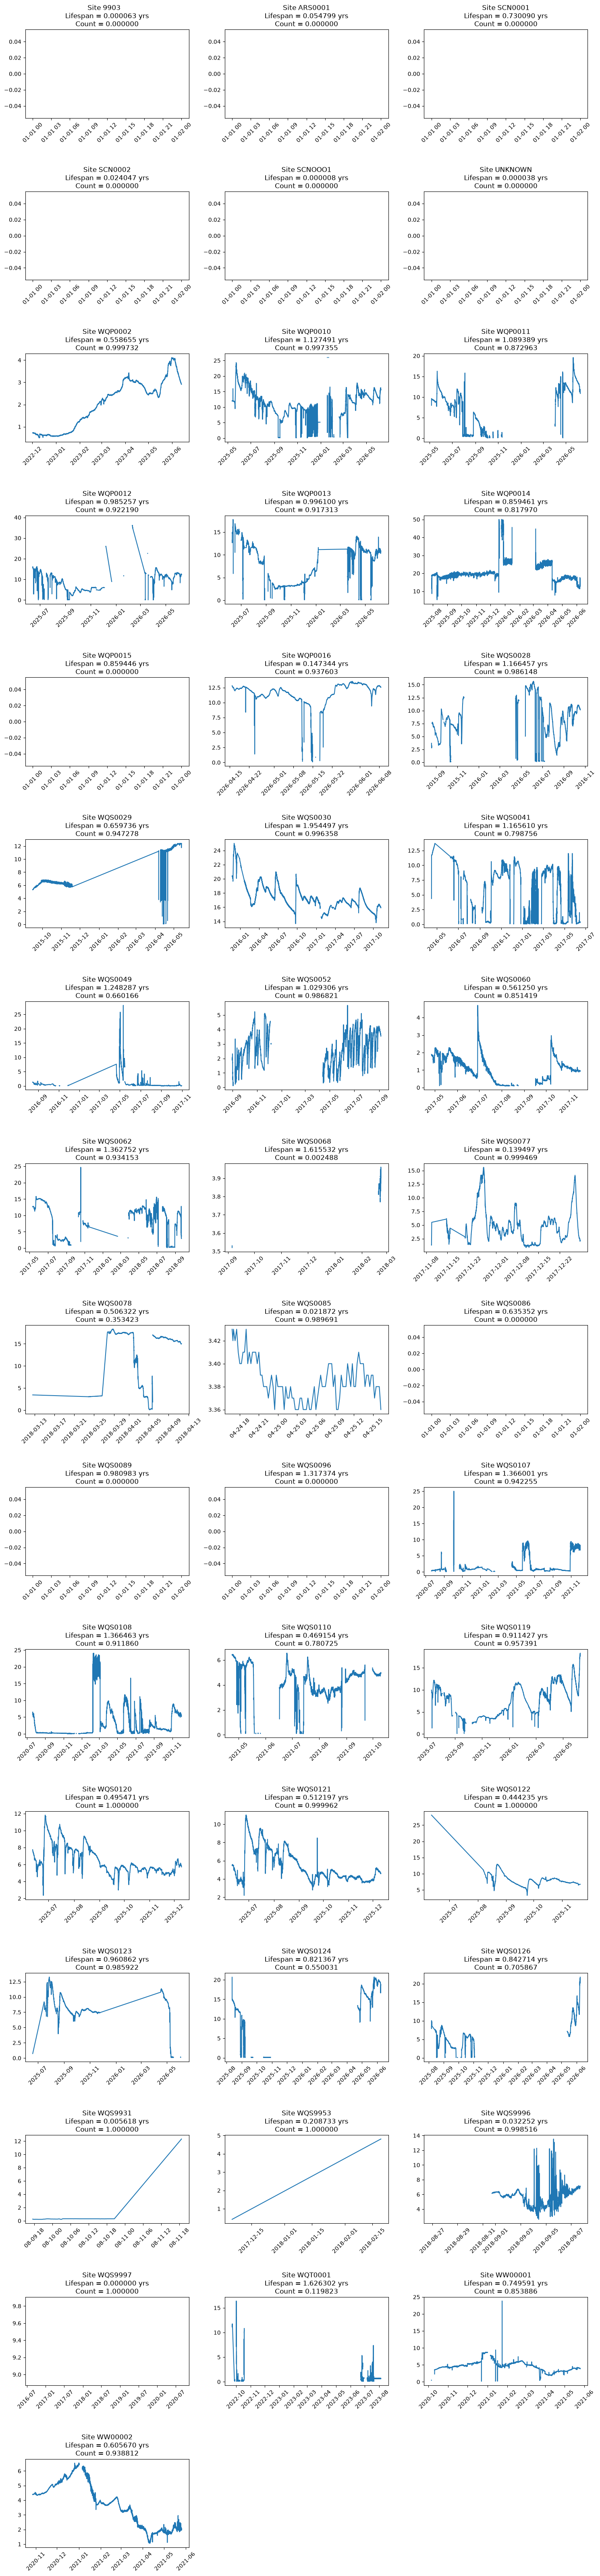

In [ ]:
# MASSIVE BIG GRAPH TABLE

import matplotlib.pyplot as plt
import math

# plot a bunch of timeseries given a list of uids
def plot_series(plot_uids):
    n_plots = len(plot_uids)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,4*n_rows))
    axes = axes.flatten() # allows iterating over subplots with single index

    # graph the things
    # since we're computing the full datetime conversion anyways
    # we also printout a comparison between the "true" late - early difference
    # and the one we computed a few cells back with the trick, 
    # just to check that they match
    print(f"{'uid':<10} {'count':<12} {'min date':<12} {'max date':<12} {'diff':<12} {'reported diff':<15}")
    for i, ax in enumerate(axes):
        if i < n_plots:
            x = pd.to_datetime(data_by_site[plot_uids[i]]['datetime'], utc=True)
            late = x.max()
            early = x.min()
            diff = (late - early).total_seconds() / (365.25 * 24 * 3600)
            y = data_by_site[plot_uids[i]]['nitrate_con']
            lifespan = site_metadata.loc[site_metadata.site_uid == plot_uids[i], 'lifespan'].iloc[0]
            count = site_metadata.loc[site_metadata.site_uid == plot_uids[i], 'data_count'].iloc[0]
            print(f"{str(plot_uids[i]):<10} {count:<12.6f} {str(early.date()):<12} {str(late.date()):<12} {float(diff):<12.6f} {float(lifespan):<15.6f}")
            ax.plot(x, y)
            ax.set_title(f'Site {plot_uids[i]}\nLifespan = {float(lifespan):.6f} yrs\nCount = {count:.6f}')
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_visible(False)

    plt.tight_layout(h_pad=3.0)
    plt.show()
    
LIFESPAN_CUTOFF = 2
plot_uids = list(site_metadata[site_metadata.lifespan <= LIFESPAN_CUTOFF].site_uid)
plot_series(plot_uids)

Plotting turned out to be quite useful, there are some graphs in here that are clearly full of bad data that might have been otherwise difficult to flag. Let's remove sites in a few steps, reexamining what remains each time.

106 (keep) + 54 (remove) = 160
-----------------------------------
uid        count        min date     max date     diff         reported diff  
9903       0.000000     2022-11-21   2022-11-21   0.000063     0.000063       
ARS0001    0.000000     2020-08-07   2020-08-27   0.054799     0.054799       
SCN0001    0.000000     2019-10-03   2020-06-26   0.730090     0.730090       
SCN0002    0.000000     2019-11-07   2019-11-16   0.024047     0.024047       
SCNOOO1    0.000000     2019-11-07   2019-11-07   0.000008     0.000008       
UNKNOWN    0.000000     2020-07-09   2020-07-09   0.000038     0.000038       
WQP0001    0.111077     2021-04-01   2024-05-01   3.082278     3.082278       
WQP0002    0.999732     2022-11-21   2023-06-13   0.558655     0.558655       
WQP0012    0.922190     2025-06-13   2026-06-08   0.985257     0.985257       
WQP0013    0.917313     2025-06-09   2026-06-08   0.996100     0.996100       
WQP0014    0.817970     2025-07-29   2026-06-08   0.859461     0

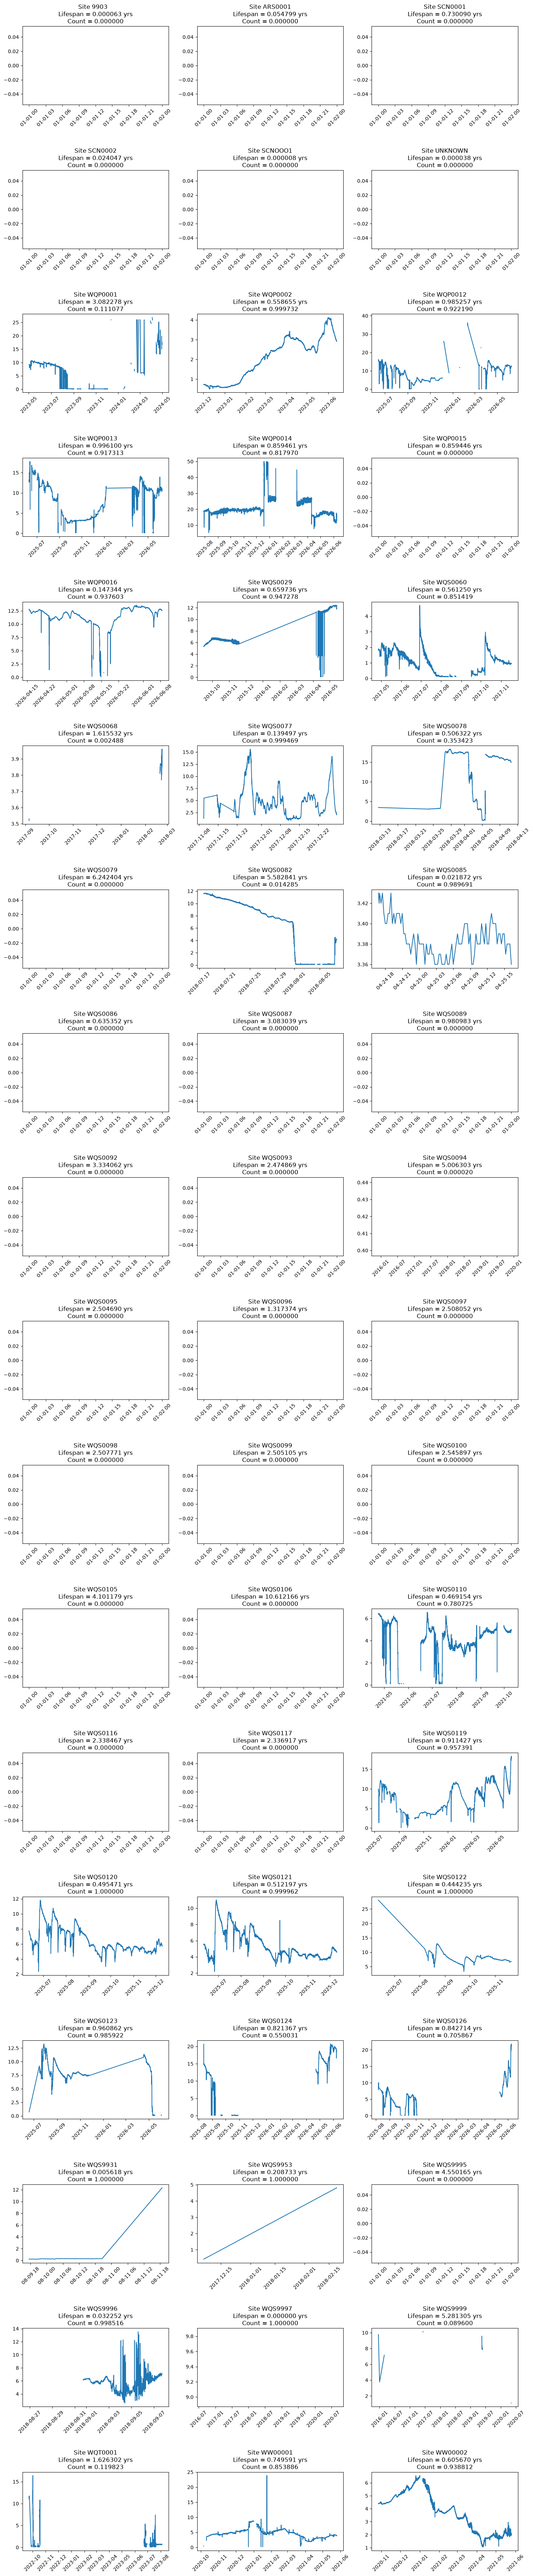

In [15]:
# split the sites in two by cutoff
def filter_sites(sparsity_cutoff, lifespan_cutoff, source=None):
    if source is None:
        source = site_metadata
       
    # store the starting number of sites
    og_length =  source.shape[0]
    
    keep = source[(source.data_count >= sparsity_cutoff) & (source.lifespan >= lifespan_cutoff)]
    remove = source[(source.data_count < sparsity_cutoff) | (source.lifespan < lifespan_cutoff)]
    
    # the combined sites
    comb_length = keep.shape[0] + remove.shape[0] 
    print(f"{keep.shape[0]} (keep) + {remove.shape[0]} (remove) = {keep.shape[0] + remove.shape[0]}")
    print("-----------------------------------")
    
    # should be equal if logic worked correctly
    assert comb_length == og_length
    
    return keep, remove

keep, remove = filter_sites(0.2, 1)
plot_series(list(remove.site_uid))

In [ ]:
# start by removing just the sites with essentially no data
keep1, remove = filter_sites(sparsity_cutoff=0.001, lifespan_cutoff=0.001)
plot_series(list(remove.site_uid))

Yeah, these had nothing, good to remove.

In [ ]:
keep2, remove = filter_sites(sparsity_cutoff=0.3, lifespan_cutoff=0.5, source=keep1)
plot_series(list(remove.site_uid))

These are all either sparse or very short. Let's look at the mid-range lifespans now.

In [ ]:
keep3, remove = filter_sites(sparsity_cutoff=0, lifespan_cutoff=3, source=keep2)
plot_series(list(remove.site_uid))

Let's check out the remaining sites

In [ ]:
plot_series(list(keep3.site_uid))

Of those remaining most of them look good, the bad ones that we haven't removed are bad in ways that are harder to detect. Let's throw them out.

In [ ]:
# most bad ones remaining seem to have lifespans under 4 or data_count under 5
keep4, remove = filter_sites(sparsity_cutoff=0.5, lifespan_cutoff=3.92, source=keep3)
remaining_bad = ["WQS0113", "WQS9901", "WQS9903", "WQS9904", "WQS9902", "WQS0091", "WQS0088", "WQS0090", "WQS0045", "WQS0075"]

keep5 = keep4[keep4.site_uid.isin(remaining_bad) == False]

keep5.shape[0]

plot_series(list(remove.site_uid))

Let's store the filtered list.

In [ ]:
# get list of the sites we're keeping
keep_uids = keep5.site_uid.unique()

# store the new relevant site metadata
site_data_filepath = "site_clean.csv"
site_df = pd.read_csv(site_data_filepath, engine='python', on_bad_lines='warn')
site_df[site_df.uid.isin(keep_uids)].to_csv("sites_of_interest.csv")

# sanity check
print(len(keep_uids))
print(site_df[site_df.uid.isin(keep_uids)].shape[0])


In [ ]:
from pathlib import Path
dir_path = Path("site_data/")

# store the full datasets of the good sites
for uid in keep_uids:
    print(dir_path / f"{str(uid).strip()}_all_data.csv")
    full_data[full_data.site_uid == uid].to_csv(dir_path / f"{str(uid).strip()}_all_data.csv", index=False)
    

In [ ]:
# I like site WQS0115 and want it back
keep_uids = list(keep5.site_uid.unique())
keep_uids.append("WQS0115")

# store the new relevant site metadata
site_data_filepath = "site_clean.csv"
site_df = pd.read_csv(site_data_filepath, engine='python', on_bad_lines='warn')
site_df[site_df.uid.isin(keep_uids)].to_csv("sites_of_interest.csv")

# sanity check
print(len(keep_uids))
print(site_df[site_df.uid.isin(keep_uids)].shape[0])

# write the site to file
uid = "WQS0115"
print(dir_path / f"{str(uid).strip()}_all_data.csv")
full_data[full_data.site_uid == uid].to_csv(dir_path / f"{str(uid).strip()}_all_data.csv", index=False)